digit dataset contains 1797 8x8 grayscale image (64 total features , each representing pixel intensity from 0 to 16 )corresponding to number 0 through 9

In [1]:
import numpy as np 
import pandas as pd 

import matplotlib.pyplot as plt
%matplotlib inline 
from sklearn.datasets import load_digits 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.svm import SVC
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [54]:
digits = load_digits()
# df=pd.DataFrame(data=digits.data , columns=digits.feature_names)
# df.head()


In [36]:
digits.keys

<function Bunch.keys()>

In [37]:
print(digits.DESCR)


.. _digits_dataset:

Optical recognition of handwritten digits dataset
--------------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 1797
:Number of Attributes: 64
:Attribute Information: 8x8 image of integer pixels in the range 0..16.
:Missing Attribute Values: None
:Creator: E. Alpaydin (alpaydin '@' boun.edu.tr)
:Date: July; 1998

This is a copy of the test set of the UCI ML hand-written digits datasets
https://archive.ics.uci.edu/ml/datasets/Optical+Recognition+of+Handwritten+Digits

The data set contains images of hand-written digits: 10 classes where
each class refers to a digit.

Preprocessing programs made available by NIST were used to extract
normalized bitmaps of handwritten digits from a preprinted form. From a
total of 43 people, 30 contributed to the training set and different 13
to the test set. 32x32 bitmaps are divided into nonoverlapping blocks of
4x4 and the number of on pixels are counted in each block. This generates
an in

In [38]:
digits.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [20]:
digits.data

array([[ 0.,  0.,  5., ...,  0.,  0.,  0.],
       [ 0.,  0.,  0., ..., 10.,  0.,  0.],
       [ 0.,  0.,  0., ..., 16.,  9.,  0.],
       ...,
       [ 0.,  0.,  1., ...,  6.,  0.,  0.],
       [ 0.,  0.,  2., ..., 12.,  0.,  0.],
       [ 0.,  0., 10., ..., 12.,  1.,  0.]], shape=(1797, 64))

In [16]:
X,y=digits.data, digits.target
print(f'shape of x :{X.shape}')
print(f'shape of y :{y.shape}')

shape of x :(1797, 64)
shape of y :(1797,)


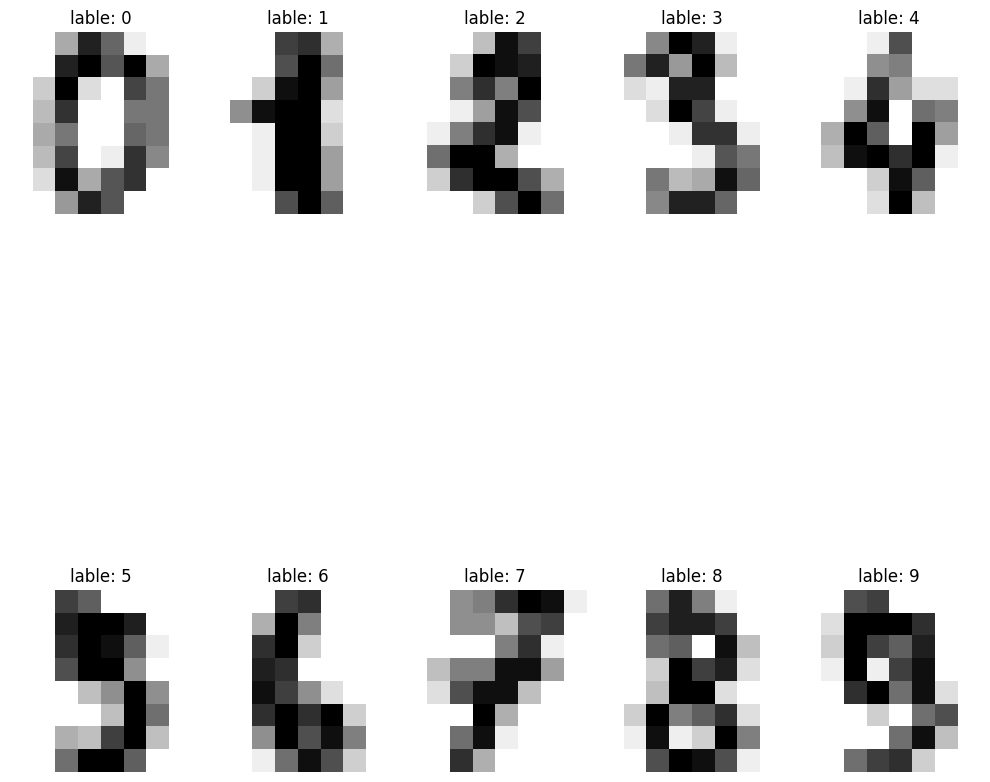

In [55]:
fig,  axes= plt.subplots(nrows=2, ncols=5, figsize=(10,15))

for i ,ax in enumerate(axes.flat):
    image_8x8=digits.data[i].reshape(8,8)

    ax.imshow(image_8x8, cmap=plt.cm.gray_r, interpolation='nearest')
    ax.set_title(f'lable: {digits.target[i]}')
    ax.axis('off')# hide axis ticks for clean visualization

plt.tight_layout()
plt.show() 

In [47]:
#stratify ensures balanced class distribution in both train and test set
x_train,x_test,y_train,y_test=train_test_split(X,y , test_size=0.20, random_state=42, stratify=y )

In [57]:
pipeline=Pipeline([('scaler',StandardScaler()),('classifier',SVC())])